# 05d — Epic-modell som regression
Testar att träna modellen att direkt prediktera ett kontinuerligt epicness-tal istället för binär epic/thin-klassificering.

**Viktigt att förstå:** detta använder dina befintliga epic/thin-mappar som mål (epic→högt, thin→lågt) med liten slumpmässig spridning. Det löser **inte** "hålet i mitten"-problemet i sig (vi har fortfarande inga riktiga mellanexempel) — men det testar om regression som **mekanism** ger en mjukare, mer användbar spridning än binär klassificering + kalibreringskurva.

In [1]:
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR  = 'data/epic_dataset'
IMG_SIZE  = (178, 178)
BATCH_SIZE = 32
MODEL_OUT = 'models/epic_detector_regression.keras'

print('TensorFlow:', tf.__version__)

TensorFlow: 2.16.2


## Bygg dataset med kontinuerliga mål
Epic-bilder får mål runt 8.5-10, thin-bilder får mål runt 0-1.5 — med slumpmässig spridning så modellen inte bara lär sig två exakta tal.

In [2]:
def collect_files(folder):
    paths = []
    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                paths.append(os.path.join(root, f))
    return paths

epic_files = collect_files(os.path.join(DATA_DIR, 'epic'))
thin_files = collect_files(os.path.join(DATA_DIR, 'thin'))

print(f'Epic: {len(epic_files)}')
print(f'Thin: {len(thin_files)}')

rng = np.random.RandomState(SEED)

epic_targets = rng.uniform(8.5, 10.0, size=len(epic_files))
thin_targets = rng.uniform(0.0, 1.5, size=len(thin_files))

all_paths   = epic_files + thin_files
all_targets = np.concatenate([epic_targets, thin_targets]).astype(np.float32)

# Blanda
perm = rng.permutation(len(all_paths))
all_paths   = [all_paths[i] for i in perm]
all_targets = all_targets[perm]

split_idx = int(len(all_paths) * 0.8)
train_paths, val_paths     = all_paths[:split_idx], all_paths[split_idx:]
train_targets, val_targets = all_targets[:split_idx], all_targets[split_idx:]

print(f'Train: {len(train_paths)}, Val: {len(val_paths)}')

Epic: 1570
Thin: 1204
Train: 2219, Val: 555


In [3]:
def load_image(path, target):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return img, target


def make_dataset(paths, targets, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, targets))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.apply(tf.data.experimental.ignore_errors())  # hoppar över trasiga filer
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_paths, train_targets, shuffle=True)
val_ds   = make_dataset(val_paths, val_targets, shuffle=False)

print('Dataset redo!')

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.
Dataset redo!


## Bygg regressionsmodellen
Samma CNN-arkitektur som `05`, men sista lagret är linjärt (`Dense(1)` utan aktivering) och loss är MSE istället för binary_crossentropy.

In [4]:
def build_regression_model():
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.03),
        tf.keras.layers.RandomZoom(0.05),
        tf.keras.layers.RandomContrast(0.10),
    ])

    model = tf.keras.Sequential([
        data_augmentation,
        tf.keras.layers.Rescaling(1./255),

        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(256, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(1)  # linjärt, ingen aktivering — regression
    ])
    return model


model = build_regression_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mse',
    metrics=['mae']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

print('Modell byggd!')

Modell byggd!


## Träna

In [5]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    callbacks=[early_stop]
)

results = model.evaluate(val_ds)
print(f'\nVal MSE: {results[0]:.3f}, Val MAE: {results[1]:.3f}')

Epoch 1/35
     70/Unknown 29s 383ms/step - loss: 35.2350 - mae: 4.9290

2026-06-22 21:17:15.990741: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/Users/nicklas.thegerstrom/ws/ml/AppliedAI/.venv_tf_stable/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


70/70 ━━━━━━━━━━━━━━━━━━━━ 31s 415ms/step - loss: 24.9990 - mae: 4.4142 - val_loss: 14.9587 - val_mae: 3.7148
Epoch 2/35


2026-06-22 21:17:18.193961: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - loss: 14.1484 - mae: 3.3659

...

2026-06-22 21:28:29.579071: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


70/70 ━━━━━━━━━━━━━━━━━━━━ 32s 455ms/step - loss: 2.1133 - mae: 1.0520 - val_loss: 2.9700 - val_mae: 1.2146
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 18.


2026-06-22 21:28:31.703703: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 2.7331 - mae: 1.1586

Val MSE: 2.733, Val MAE: 1.159


2026-06-22 21:28:33.789435: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


## Utvärdering — fördelning av predikterade värden
Det viktiga testet: får vi en jämnare spridning över hela 0-10-skalan nu, eller klumpar allt ihop sig vid extremerna igen?

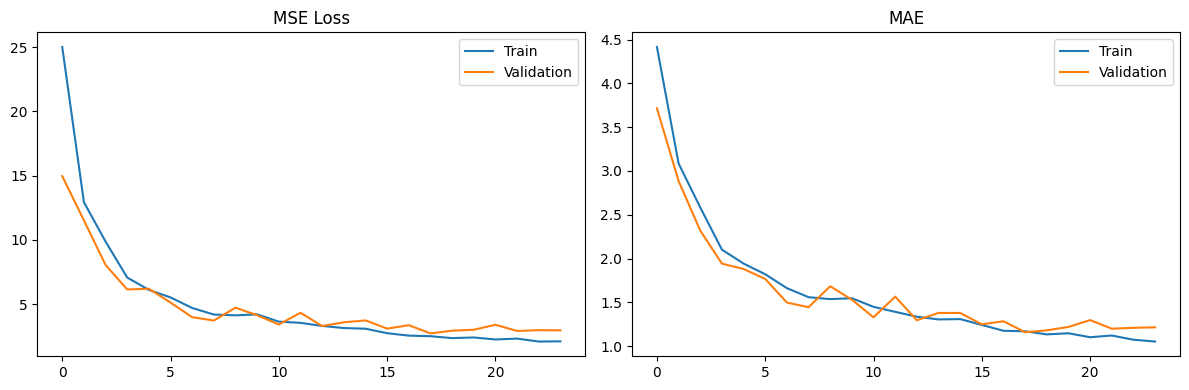

2026-06-22 21:29:43.697202: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


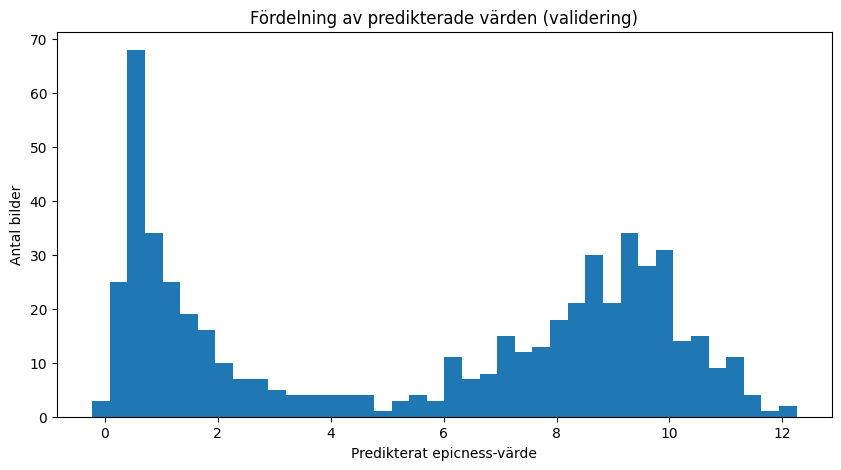

Min: -0.23, Max: 12.25
Median: 6.97
Andel mellan 3-7 (mellanzonen): 11.2%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('MSE Loss')
axes[0].legend()
axes[1].plot(history.history['mae'], label='Train')
axes[1].plot(history.history['val_mae'], label='Validation')
axes[1].set_title('MAE')
axes[1].legend()
plt.tight_layout()
plt.show()

val_preds = model.predict(val_ds, verbose=0).flatten()

plt.figure(figsize=(10, 5))
plt.hist(val_preds, bins=40)
plt.xlabel('Predikterat epicness-värde')
plt.ylabel('Antal bilder')
plt.title('Fördelning av predikterade värden (validering)')
plt.show()

print(f'Min: {val_preds.min():.2f}, Max: {val_preds.max():.2f}')
print(f'Median: {np.median(val_preds):.2f}')
print(f'Andel mellan 3-7 (mellanzonen): {((val_preds >= 3) & (val_preds <= 7)).mean()*100:.1f}%')

## Spara

In [7]:
os.makedirs('models', exist_ok=True)
model.save(MODEL_OUT)
print(f'Sparad: {MODEL_OUT}')

Sparad: models/epic_detector_regression.keras
